In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
import statsmodels.formula.api as smf
import scipy.stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib import pyplot as plt


In [4]:
train = pd.read_csv('train.csv', index_col=0)
train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.5+ MB


In [6]:
train.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
max,4.000000,1.000000,70.000000,7.000000,1.000000


In [7]:
print("\nMissing values per column:")
print(train.isna().sum())


Missing values per column:
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64


In [8]:
categorical_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
train_encoded = pd.get_dummies(train, columns=categorical_cols)

In [9]:
train_encoded.dtypes

num_lanes                   int64
curvature                 float64
speed_limit                 int64
road_signs_present           bool
public_road                  bool
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
road_type_highway            bool
road_type_rural              bool
road_type_urban              bool
lighting_daylight            bool
lighting_dim                 bool
lighting_night               bool
weather_clear                bool
weather_foggy                bool
weather_rainy                bool
time_of_day_afternoon        bool
time_of_day_evening          bool
time_of_day_morning          bool
dtype: object

In [10]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
scaler = StandardScaler()
train_encoded[numeric_cols] = scaler.fit_transform(train_encoded[numeric_cols])

In [11]:
print(train_encoded.columns.tolist())


['num_lanes', 'curvature', 'speed_limit', 'road_signs_present', 'public_road', 'holiday', 'school_season', 'num_reported_accidents', 'accident_risk', 'road_type_highway', 'road_type_rural', 'road_type_urban', 'lighting_daylight', 'lighting_dim', 'lighting_night', 'weather_clear', 'weather_foggy', 'weather_rainy', 'time_of_day_afternoon', 'time_of_day_evening', 'time_of_day_morning']


In [12]:
print(train_encoded[numeric_cols].describe())


          num_lanes     curvature   speed_limit  num_reported_accidents
count  5.177540e+05  5.177540e+05  5.177540e+05            5.177540e+05
mean   1.129998e-16 -1.532167e-16  2.172782e-16           -1.766222e-17
std    1.000001e+00  1.000001e+00  1.000001e+00            1.000001e+00
min   -1.331192e+00 -1.793050e+00 -1.337212e+00           -1.325918e+00
25%   -1.331192e+00 -8.391425e-01 -7.038396e-01           -2.097968e-01
50%   -4.386798e-01  7.807664e-02 -7.046739e-02           -2.097968e-01
75%    4.538321e-01  8.118520e-01  8.795909e-01            9.063240e-01
max    1.346344e+00  1.875826e+00  1.512963e+00            6.486928e+00


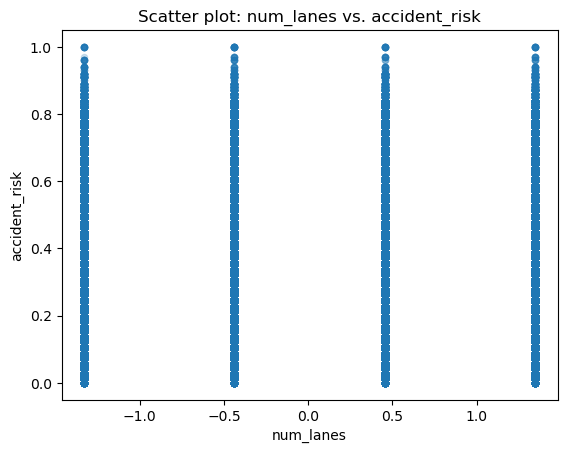

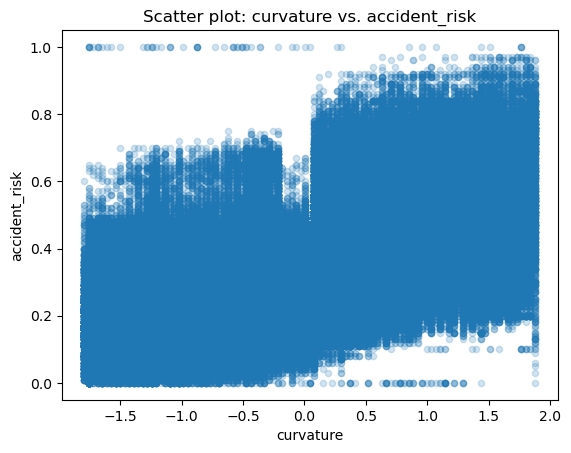

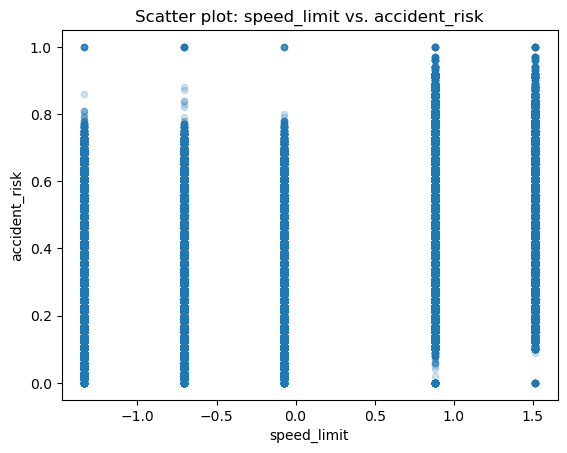

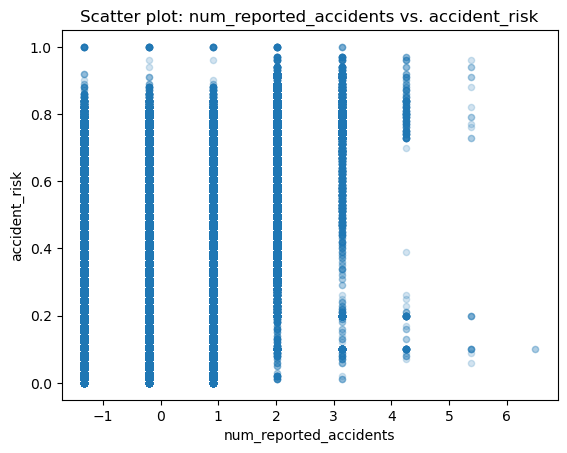

In [13]:
import matplotlib.pyplot as plt

# Example for numeric features vs. accident_risk
features = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

for col in features:
    train_encoded.plot.scatter(x=col, y='accident_risk', alpha=0.2)
    plt.title(f'Scatter plot: {col} vs. accident_risk')
    plt.show()


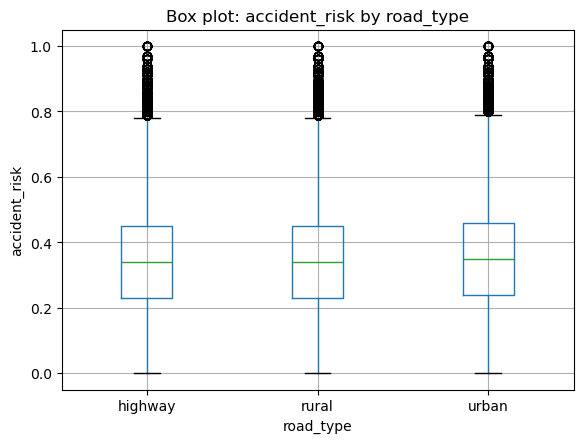

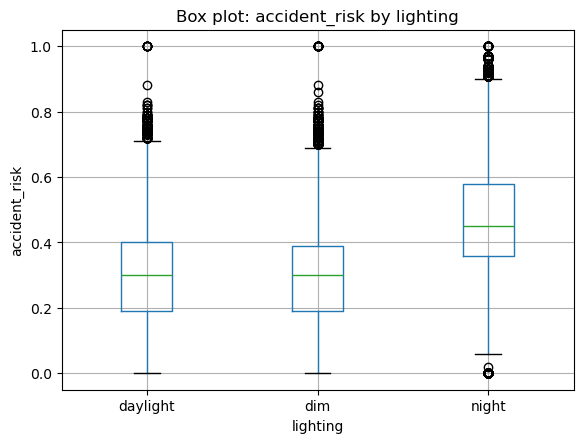

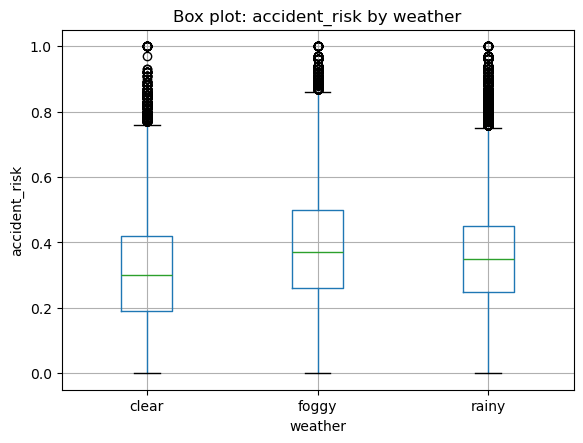

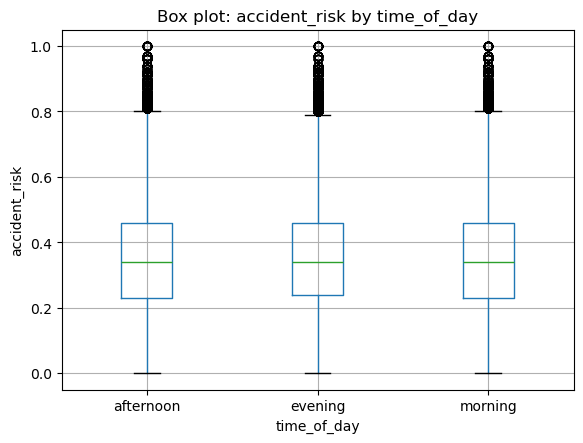

In [14]:
# If you still have original categorical columns
for cat in ['road_type', 'lighting', 'weather', 'time_of_day']:
    train.boxplot(column='accident_risk', by=cat)
    plt.title(f'Box plot: accident_risk by {cat}')
    plt.suptitle('')
    plt.xlabel(cat)
    plt.ylabel('accident_risk')
    plt.show()


In [15]:
corr_matrix = train_encoded.corr()
print(corr_matrix['accident_risk'].sort_values(ascending=False))


accident_risk             1.000000
curvature                 0.543946
lighting_night            0.465798
speed_limit               0.430898
num_reported_accidents    0.213891
weather_foggy             0.149758
holiday                   0.051129
weather_rainy             0.036137
public_road               0.031032
road_type_urban           0.021463
time_of_day_evening       0.010032
road_signs_present        0.000629
school_season            -0.000977
time_of_day_afternoon    -0.004016
num_lanes                -0.006003
time_of_day_morning      -0.006019
road_type_rural          -0.010121
road_type_highway        -0.011285
weather_clear            -0.185085
lighting_daylight        -0.215109
lighting_dim             -0.233032
Name: accident_risk, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Select features based on correlation analysis
selected_features = [
    'curvature',
    'lighting_night',
    'speed_limit',
    'num_reported_accidents',
    'weather_foggy',
    'lighting_dim',
    'lighting_daylight',
    'weather_clear'
]
X = train_encoded[selected_features]
y = train_encoded['accident_risk']

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Calculate RMSE manually without 'squared' parameter
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Random Forest Regressor:")
print("RMSE:", rmse_rf)
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

print("\nLinear Regression:")
print("RMSE:", rmse_lr)
print("MAE:", mean_absolute_error(y_test, y_pred_lr))


Random Forest Regressor:
RMSE: 0.057407225450626424
MAE: 0.04445393290886406

Linear Regression:
RMSE: 0.07353868604242467
MAE: 0.05831416824328438


In [17]:
# Predict accident risk for all rows
predicted_risk = rf.predict(X)

# Create results DataFrame with id and predictions
results = pd.DataFrame({
    'id': train.index,  # Replace with your actual id column name
    'accident_risk': predicted_risk
})

# Display the first few rows of the results DataFrame
print(results.head())

# Optionally, display summary statistics to understand prediction range
print(results['accident_risk'].describe())


   id  accident_risk
0   0       0.131663
1   1       0.319223
2   2       0.381763
3   3       0.136775
4   4       0.471024
count    517754.000000
mean          0.352436
std           0.157127
min           0.015064
25%           0.243214
50%           0.338013
75%           0.454395
max           0.941485
Name: accident_risk, dtype: float64


In [18]:
results.tail()

,id,accident_risk
517749,517749,0.343550
517750,517750,0.242005
517751,517751,0.311814
517752,517752,0.444431
517753,517753,0.195602


In [19]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_rf)
print("R-squared:", r2)


R-squared: 0.8806473146477801


In [20]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validation R2 scores:", scores)
print("Average R2:", scores.mean())


Cross-validation R2 scores: [0.880366   0.88302477 0.88128264 0.88132185 0.88254698]
Average R2: 0.8817084476103668


Feature correlation with accident risk:
accident_risk             1.000000
curvature                 0.543946
lighting_night            0.465798
speed_limit               0.430898
num_reported_accidents    0.213891
weather_foggy             0.149758
holiday                   0.051129
weather_rainy             0.036137
public_road               0.031032
road_type_urban           0.021463
time_of_day_evening       0.010032
road_signs_present        0.000629
school_season            -0.000977
time_of_day_afternoon    -0.004016
num_lanes                -0.006003
time_of_day_morning      -0.006019
road_type_rural          -0.010121
road_type_highway        -0.011285
weather_clear            -0.185085
lighting_daylight        -0.215109
lighting_dim             -0.233032
Name: accident_risk, dtype: float64


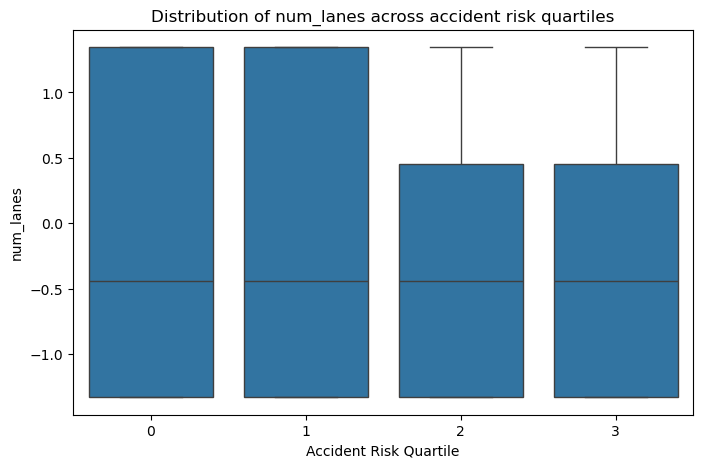

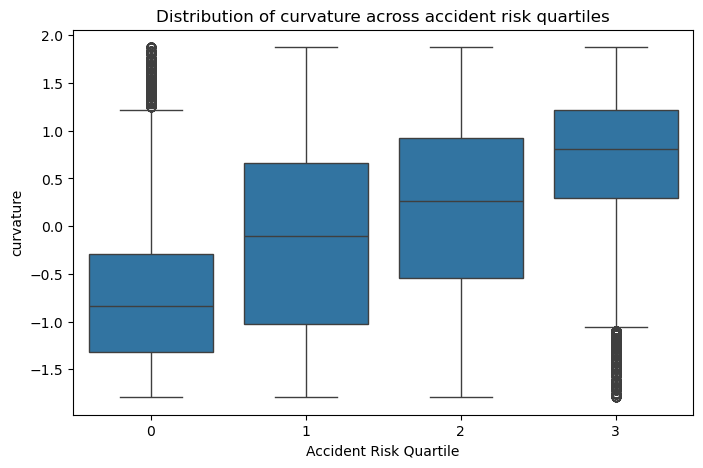

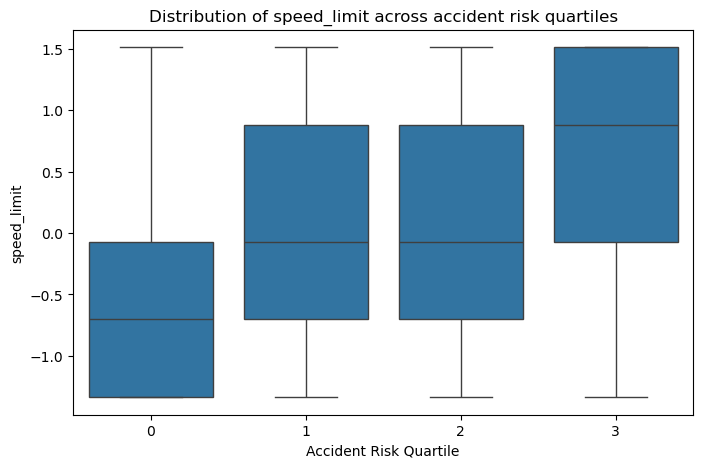

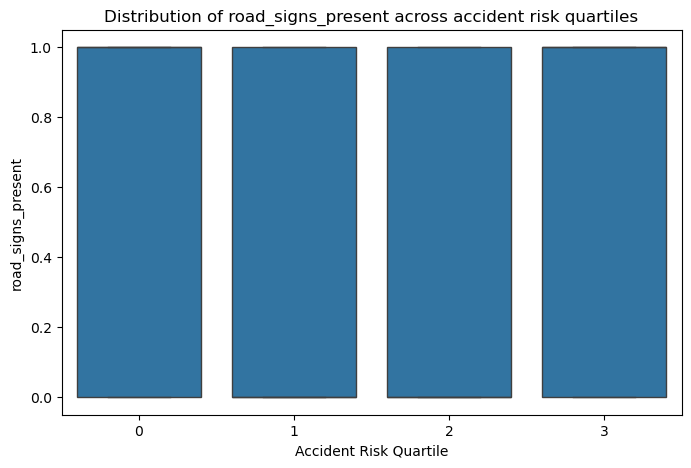

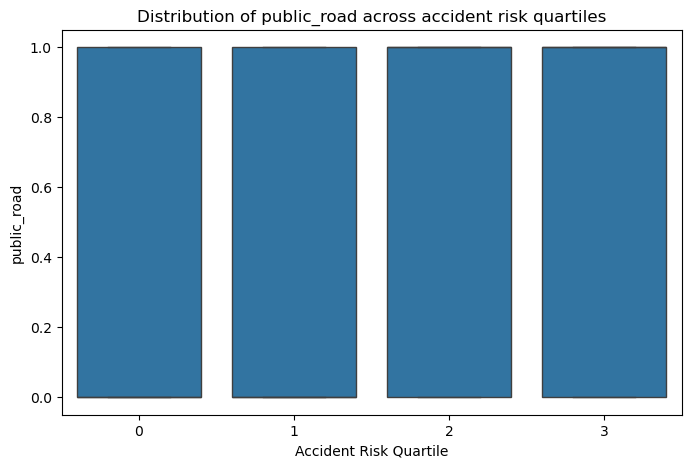

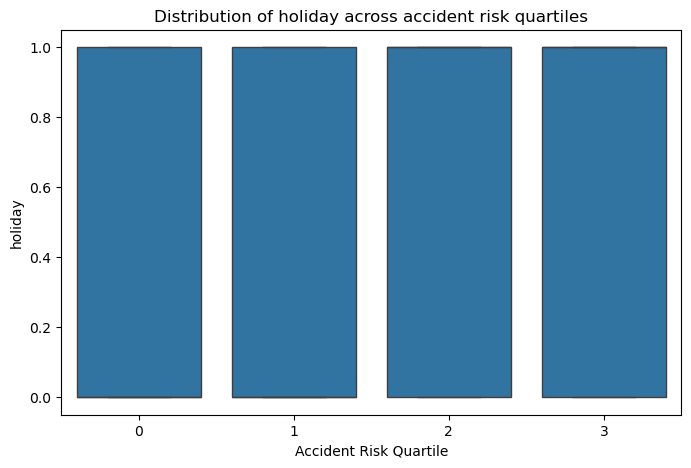

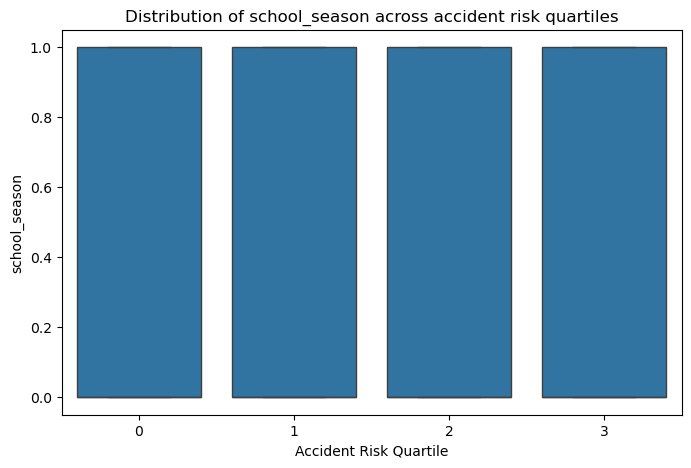

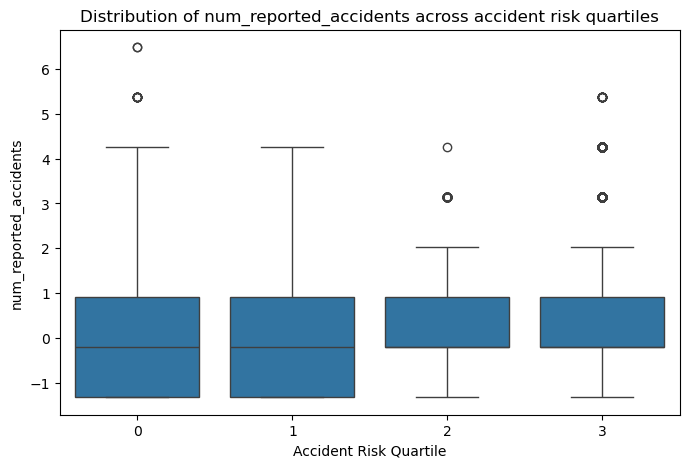

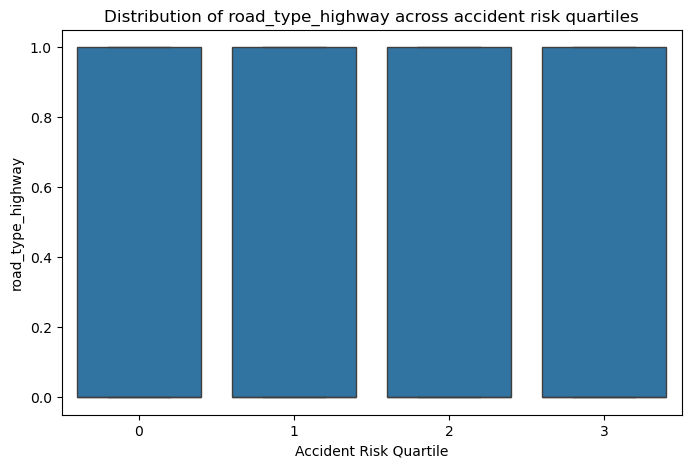

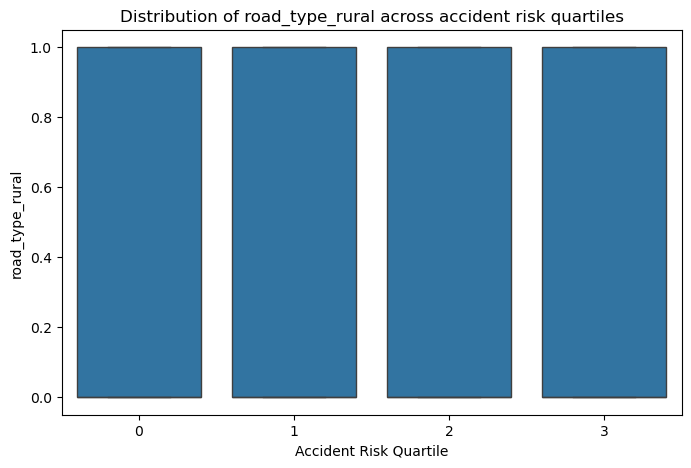

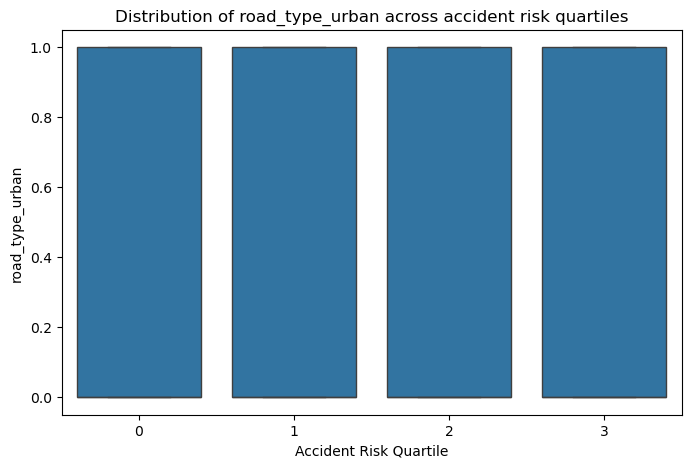

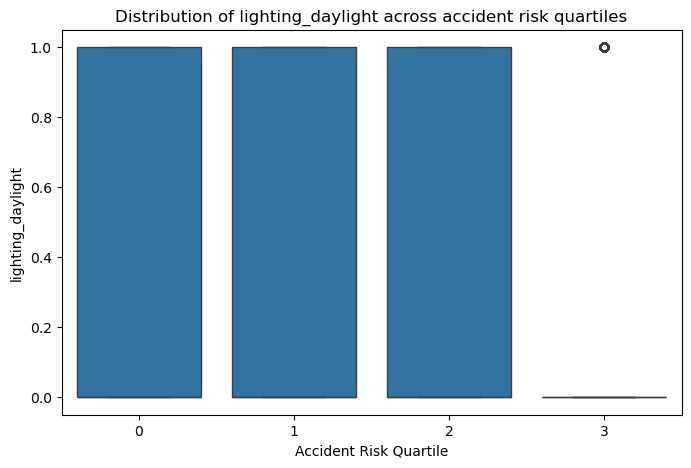

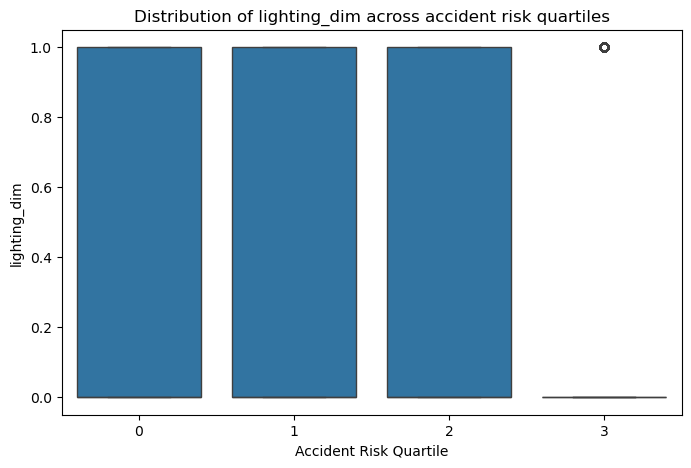

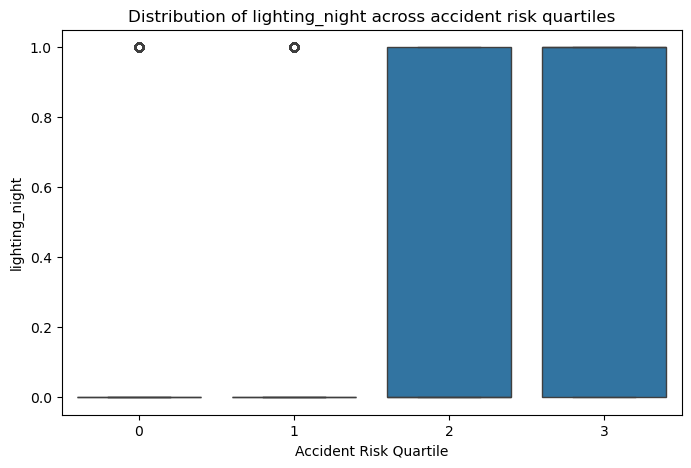

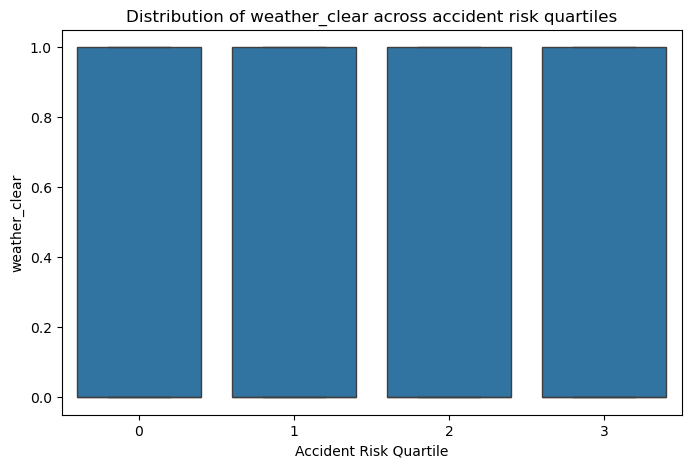

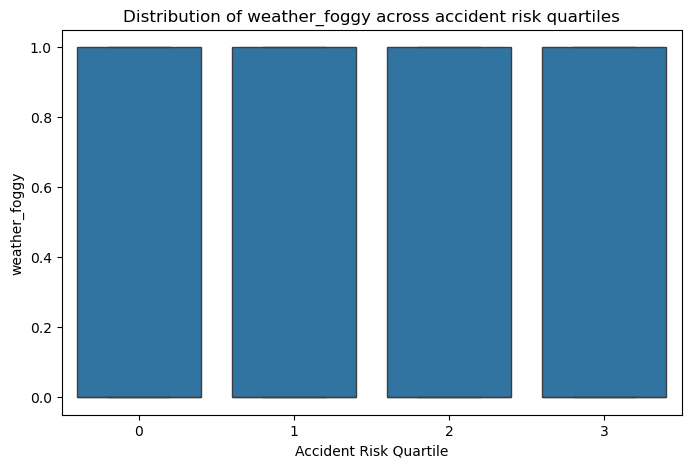

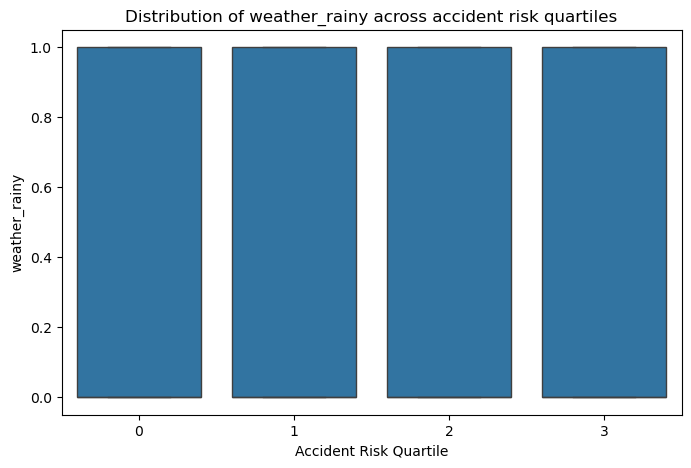

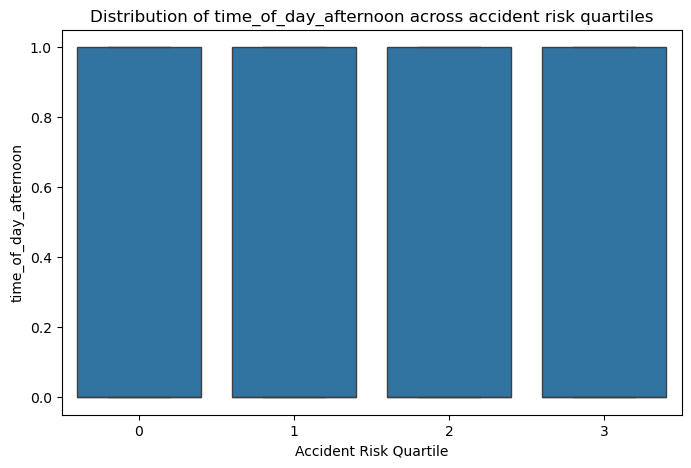

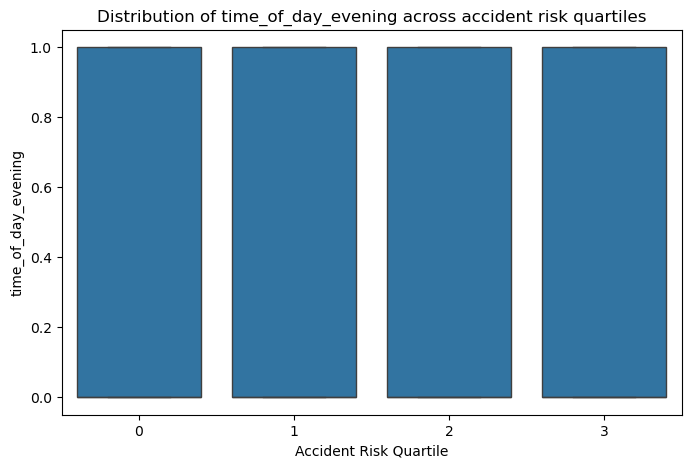

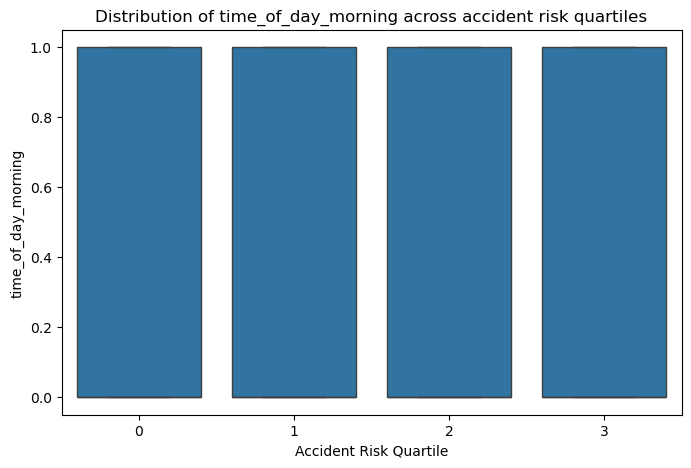

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List of features to check for leakage potential excluding the target itself
features_to_check = [
    'num_lanes', 'curvature', 'speed_limit', 'road_signs_present', 'public_road',
    'holiday', 'school_season', 'num_reported_accidents', 'road_type_highway',
    'road_type_rural', 'road_type_urban', 'lighting_daylight', 'lighting_dim',
    'lighting_night', 'weather_clear', 'weather_foggy', 'weather_rainy',
    'time_of_day_afternoon', 'time_of_day_evening', 'time_of_day_morning'
]

# 1. Correlation check
correlations = train_encoded[features_to_check + ['accident_risk']].corr()['accident_risk'].sort_values(ascending=False)
print("Feature correlation with accident risk:")
print(correlations)

# 2. Visual inspection for suspiciously high correlation (>0.6 suggested threshold)
for feature in correlations.index[1:]:  # skip target itself at index 0
    corr_value = correlations[feature]
    if abs(corr_value) > 0.6:
        print(f"\nHigh correlation detected: {feature} (corr={corr_value:.2f})")
        # Plot feature vs target
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=train_encoded[feature], y=train_encoded['accident_risk'], alpha=0.4)
        plt.title(f'Scatter plot: {feature} vs accident_risk')
        plt.show()

# 3. Distribution check: Compare feature distribution across accident risk buckets
train_encoded['risk_bucket'] = pd.qcut(train_encoded['accident_risk'], q=4, labels=False)  # quartiles for categorization
for feature in features_to_check:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='risk_bucket', y=feature, data=train_encoded)
    plt.title(f'Distribution of {feature} across accident risk quartiles')
    plt.xlabel('Accident Risk Quartile')
    plt.show()


In [22]:
# Save the predictions with id to CSV file
results.to_csv('predicted_accident_risk.csv', index=False)
print("Predictions saved to predicted_accident_risk.csv")

Predictions saved to predicted_accident_risk.csv


In [23]:
test = pd.read_csv('test.csv', index_col=0)
test.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
id,,,,,,,,,,,,
517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


In [24]:
print(test.dtypes)

road_type                  object
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present           bool
public_road                  bool
time_of_day                object
holiday                      bool
school_season                bool
num_reported_accidents      int64
dtype: object


In [25]:
categorical_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
test_encoded = pd.get_dummies(train, columns=categorical_cols)

In [26]:
print(test_encoded.dtypes)

num_lanes                   int64
curvature                 float64
speed_limit                 int64
road_signs_present           bool
public_road                  bool
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
road_type_highway            bool
road_type_rural              bool
road_type_urban              bool
lighting_daylight            bool
lighting_dim                 bool
lighting_night               bool
weather_clear                bool
weather_foggy                bool
weather_rainy                bool
time_of_day_afternoon        bool
time_of_day_evening          bool
time_of_day_morning          bool
dtype: object


In [27]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
scaler = StandardScaler()
test_encoded[numeric_cols] = scaler.fit_transform(train_encoded[numeric_cols])

In [28]:
corr_matrix = test_encoded.corr()
print(corr_matrix['accident_risk'].sort_values(ascending=False))


accident_risk             1.000000
curvature                 0.543946
lighting_night            0.465798
speed_limit               0.430898
num_reported_accidents    0.213891
weather_foggy             0.149758
holiday                   0.051129
weather_rainy             0.036137
public_road               0.031032
road_type_urban           0.021463
time_of_day_evening       0.010032
road_signs_present        0.000629
school_season            -0.000977
time_of_day_afternoon    -0.004016
num_lanes                -0.006003
time_of_day_morning      -0.006019
road_type_rural          -0.010121
road_type_highway        -0.011285
weather_clear            -0.185085
lighting_daylight        -0.215109
lighting_dim             -0.233032
Name: accident_risk, dtype: float64


In [29]:
print("train_encoded:", train_encoded.shape)
print("test_encoded:", test_encoded.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("test:", test.shape)

train_encoded: (517754, 22)
test_encoded: (517754, 21)
X_train: (414203, 8)
X_test: (103551, 8)
test: (172585, 12)


In [34]:
train = pd.read_csv("train.csv", index_col=0)
test = pd.read_csv("test.csv", index_col=0)

# --- Define columns ---
categorical_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
numeric_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

# --- Encode separately ---
train_encoded = pd.get_dummies(train, columns=categorical_cols)
test_encoded = pd.get_dummies(test, columns=categorical_cols)

# --- Align safely by columns only (not by index) ---
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# --- Scale numeric features ---
scaler = StandardScaler()
train_encoded[numeric_cols] = scaler.fit_transform(train_encoded[numeric_cols])
test_encoded[numeric_cols] = scaler.transform(test_encoded[numeric_cols])

# --- Select features (only keep ones that exist) ---
selected_features = [
    'curvature',
    'lighting_night',
    'speed_limit',
    'num_reported_accidents',
    'weather_foggy',
    'lighting_dim',
    'lighting_daylight',
    'weather_clear'
]
selected_features = [f for f in selected_features if f in train_encoded.columns]

# --- Train & Predict ---
X_train = train_encoded[selected_features]
y_train = train_encoded['accident_risk']
X_test = test_encoded[selected_features]

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
test['pred_rf'] = rf.predict(X_test)

lr = LinearRegression()
lr.fit(X_train, y_train)
test['pred_lr'] = lr.predict(X_test)

# --- Save results ---
results = test[['pred_rf', 'pred_lr']]
results.to_csv('predictions.csv', index=False)

print("Train shape:", train_encoded.shape)
print("Test shape:", test_encoded.shape)
print("Predictions saved to predictions.csv")
print(results.head())

Train shape: (517754, 21)
Test shape: (172585, 21)
Predictions saved to predictions.csv
         pred_rf   pred_lr
id                        
517754  0.290838  0.366051
517755  0.113112  0.157324
517756  0.182441  0.208878
517757  0.337896  0.434446
517758  0.374748  0.328085


In [36]:
results = pd.DataFrame({
    'id': test.index,
    'pred_rf': test['pred_rf'],
    'pred_lr': test['pred_lr']
})
results.to_csv('predictions.csv', index=False)
